<a href="https://colab.research.google.com/github/Naincy-20-06/Machine_Learning_projects/blob/Naincy-20-06-patch-1/food_delivery_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Food delivery Time Prediction by KNN ALgorithm



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import learning_curve

Auxiliary Function for Feature Engineering (Haversine Formula)

In [ ]:
def haversine(lat1, lon1, lat2, lon2):

    R = 6371  # Radius of Earth in kilometers
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    distance = R * c
    return distance

## PHASE 1: Data Preprocessing & Feature Engineering

In [ ]:
import pandas as pd

try:
    df = pd.read_csv('/content/Food_Delivery_Time_Prediction.csv')
    print("Successfully loaded 'Food_Delivery_Time_Prediction.csv'.")
except FileNotFoundError:
    raise FileNotFoundError("Error: 'Food_Delivery_Time_Prediction.csv' not found. Please ensure the file is in the correct directory.")

Successfully loaded 'Food_Delivery_Time_Prediction.csv'.


In [ ]:
import pandas as pd
import numpy as np

# Loading the dataset
try:
    # Assuming the correct filename based on assignment context might be 'food_delivery_dataset.csv'
    # but falling back to the current one if specific instructions differ.
    df = pd.read_csv('/content/Food_Delivery_Time_Prediction.csv')
    print("Dataset loaded successfully.")
except Exception as e:
    print(f"Error loading dataset: {e}")

# Create target based on Delivery_Time
if 'Delivery_Time' in df.columns:
    threshold = df['Delivery_Time'].median()
    df['Delivery_Status'] = (df['Delivery_Time'] > threshold).astype(int)
    print(f"Target 'Delivery_Status' created using median Delivery_Time: {threshold} mins")
else:
    # Fallback/Safety check for the column name
    print("Warning: 'Delivery_Time' column not found. Please check dataset schema.")

Dataset loaded successfully.
Target 'Delivery_Status' created using median Delivery_Time: 72.775 mins


In [ ]:
# Identify feature types
numeric_features = ['Delivery_Person_Age', 'Delivery_Person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude']
categorical_features = ['Weather_Conditions', 'Road_Traffic_Density', 'Vehicle_Condition', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City']

# Filter features that actually exist in the dataframe
numeric_features = [f for f in numeric_features if f in df.columns]
categorical_features = [f for f in categorical_features if f in df.columns]

# Define Preprocessing Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X = df[numeric_features + categorical_features]
y = df['Delivery_Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Handle Missing Values through Imputation

In [ ]:
categorical_cols_to_impute = ['Weather_Condition', 'Traffic_Condition', 'Vehicle_Type']

for col in categorical_cols_to_impute:
    if col in df.columns and df[col].isnull().any():
        # Impute with the mode
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"Missing values in '{col}' imputed with mode: '{mode_val}'.")

### Handling Categorical Missing Values



In [ ]:
for col in ['Missing_Column', 'Other_Feature']:
    if col in df.columns:
        if df[col].isnull().any():
            if pd.api.types.is_numeric_dtype(df[col]):
                df[col].fillna(df[col].mean(), inplace=True)
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)

1. Calculate Geographic Distance (Haversine formula)

In [ ]:
import re

def extract_lat_lon(location_str):
    # Handle NaN or non-string values gracefully
    if pd.isna(location_str) or not isinstance(location_str, str):
        return np.nan, np.nan
    match = re.match(r'\(([^,]+),\s*([^)]+)\)', location_str)
    if match:
        try:
            return float(match.group(1)), float(match.group(2))
        except ValueError:
            return np.nan, np.nan
    return np.nan, np.nan

# Extract latitude and longitude from 'Customer_Location' if it exists
if 'Customer_Location' in df.columns:
    df[['Customer_lat', 'Customer_lon']] = df['Customer_Location'].apply(lambda x: pd.Series(extract_lat_lon(x)))
    print("Extracted Customer latitude and longitude coordinates.")

# Extract latitude and longitude from 'Restaurant_Location' if it exists
if 'Restaurant_Location' in df.columns:
    df[['Restaurant_lat', 'Restaurant_lon']] = df['Restaurant_Location'].apply(lambda x: pd.Series(extract_lat_lon(x)))
    print("Extracted Restaurant latitude and longitude coordinates.")

lat_lon_cols = ['Customer_lat', 'Customer_lon', 'Restaurant_lat', 'Restaurant_lon']
if all(col in df.columns for col in lat_lon_cols):
    df['Distance_km'] = df.apply(lambda row: haversine(
        row['Customer_lat'], row['Customer_lon'],
        row['Restaurant_lat'], row['Restaurant_lon']
    ), axis=1)
    print("Distance_km calculated from Customer/Restaurant coordinates.")
elif 'Distance_km' in df.columns:
    print("'Distance_km' column already exists in the DataFrame, skipping haversine calculation.")
else:
    print("Warning: Neither lat/lon coordinates nor 'Distance_km' found in DataFrame. Cannot proceed with distance-based features.")


Extracted Customer latitude and longitude coordinates.
Extracted Restaurant latitude and longitude coordinates.
Distance_km calculated from Customer/Restaurant coordinates.


2. Create Binary Categories for Delivery Status

In [ ]:
# First, let's look at the distance statistics to find a good split point
print("Distance Statistics:")
print(df['Distance_km'].describe())

# We will use the median to ensure a 50/50 split for a balanced dataset
DISTANCE_THRESHOLD = df['Distance_km'].median()
print(f"\nUsing Median Distance as Threshold: {DISTANCE_THRESHOLD:.2f} km")

df['Delivery_Status'] = df['Distance_km'].apply(
    lambda x: 1 if x >= DISTANCE_THRESHOLD else 0
)

# Prepare features and target
features_to_drop = ['Distance_km']
X = df.drop(features_to_drop + ['Delivery_Status'], axis=1)
y = df['Delivery_Status']

# Verify new distribution
print("\nNew Delivery_Status distribution:")
print(df['Delivery_Status'].value_counts())

Distance Statistics:
count     200.000000
mean      603.037915
std       269.796797
min        29.871927
25%       389.197293
50%       558.788921
75%       807.602442
max      1299.244267
Name: Distance_km, dtype: float64

Using Median Distance as Threshold: 558.79 km

New Delivery_Status distribution:
Delivery_Status
1    100
0    100
Name: count, dtype: int64


Use one-hot encoding for nominal categorical features

In [ ]:
import pandas as pd

# Identify all object (string) dtype columns that are still in X for one-hot encoding
categorical_cols_to_encode = X.select_dtypes(include='object').columns.tolist()

# Apply one-hot encoding only to the columns that still exist in X
if categorical_cols_to_encode:
    X = pd.get_dummies(X, columns=categorical_cols_to_encode, drop_first=True)

# Filter continuous_features to include only those present in X
all_possible_continuous_features = ['Distance', 'Customer_lat', 'Customer_lon', 'Restaurant_lat', 'Restaurant_lon']
continuous_features = [col for col in all_possible_continuous_features if col in X.columns]

# Apply StandardScaler only if there are continuous features to scale
if continuous_features:
    scaler = StandardScaler()
    X[continuous_features] = scaler.fit_transform(X[continuous_features])

# Drop identifier and original string location columns which are not needed after feature engineering
columns_to_drop_from_X = ['Order_ID', 'Customer_Location', 'Restaurant_Location']
X = X.drop(columns=[col for col in columns_to_drop_from_X if col in X.columns], axis=1)

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"\nTraining set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")


Training set size: 140
Testing set size: 60


# PHASE 2: Classification using Naive Bayes, KNN, and Decision Tree


In [ ]:

models = {}
results = []
roc_data = {}

def evaluate_model(name, model, X_test, y_test, y_pred, y_prob):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    roc_data[name] = (fpr, tpr, roc_auc)

    print(f"\n--- {name} Evaluation ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


1. Naive Bayes Classifier (Gaussian Naive Bayes)


In [ ]:
nb = GaussianNB()

# Impute any remaining NaNs before fitting the model
X_train_imputed = X_train.fillna(X_train.mean())
X_test_imputed = X_test.fillna(X_train.mean()) # Use training set mean for consistency

nb.fit(X_train_imputed, y_train)
y_pred_nb = nb.predict(X_test_imputed)

# Handle cases where predict_proba might return only one column (e.g., if y_train is single-class)
proba_output = nb.predict_proba(X_test_imputed)
if proba_output.shape[1] == 1:
    y_prob_nb = proba_output[:, 0] # If only one class is predicted, this is the probability of that class
else:
    y_prob_nb = proba_output[:, 1] # Otherwise, take the probability of the positive class (class 1)

models['Naive Bayes'] = nb
evaluate_model('Naive Bayes', nb, X_test_imputed, y_test, y_pred_nb, y_prob_nb)


--- Naive Bayes Evaluation ---
Accuracy: 0.4667
Precision: 0.4828
Recall: 0.9333
F1-Score: 0.6364
Confusion Matrix:
 [[ 0 30]
 [ 2 28]]


 2. K-Nearest Neighbors (KNN) with Hyperparameter Tuning

In [ ]:
param_grid_knn = {'n_neighbors': np.arange(1, 21)} # Testing K from 1 to 20

# Impute any remaining NaNs in X_train and X_test before fitting KNN
X_train_knn_imputed = X_train.fillna(X_train.mean())
X_test_knn_imputed = X_test.fillna(X_train.mean()) # Use training set mean for consistency

knn_grid = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_knn_imputed, y_train)
optimal_k = knn_grid.best_params_['n_neighbors']

knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train_knn_imputed, y_train)
y_pred_knn = knn.predict(X_test_knn_imputed)

# Handle cases where predict_proba might return only one column (e.g., if y_train is single-class)
proba_output_knn = knn.predict_proba(X_test_knn_imputed)
if proba_output_knn.shape[1] == 1:
    y_prob_knn = proba_output_knn[:, 0] # If only one class is predicted, this is the probability of that class
else:
    y_prob_knn = proba_output_knn[:, 1] # Otherwise, take the probability of the positive class (class 1)

models['KNN'] = knn
evaluate_model(f'KNN (K={optimal_k})', knn, X_test_knn_imputed, y_test, y_pred_knn, y_prob_knn)


--- KNN (K=1) Evaluation ---
Accuracy: 0.5167
Precision: 0.5152
Recall: 0.5667
F1-Score: 0.5397
Confusion Matrix:
 [[14 16]
 [13 17]]


3. Decision Tree with Hyperparameter Tuning

In [ ]:
param_grid_dt = {
    'max_depth': [3, 5, 7, 9, 11],
    'min_samples_split': [2, 5, 10]
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train, y_train)
best_dt_params = dt_grid.best_params_

dt = DecisionTreeClassifier(**best_dt_params, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Handle cases where predict_proba might return only one column (e.g., if y_train is single-class)
proba_output_dt = dt.predict_proba(X_test)
if proba_output_dt.shape[1] == 1:
    y_prob_dt = proba_output_dt[:, 0] # If only one class is predicted, this is the probability of that class
else:
    y_prob_dt = proba_output_dt[:, 1] # Otherwise, take the probability of the positive class (class 1)

models['Decision Tree'] = dt
evaluate_model(f'Decision Tree (Depth={best_dt_params["max_depth"]})', dt, X_test, y_test, y_pred_dt, y_prob_dt)


--- Decision Tree (Depth=7) Evaluation ---
Accuracy: 0.6833
Precision: 0.7037
Recall: 0.6333
F1-Score: 0.6667
Confusion Matrix:
 [[22  8]
 [11 19]]


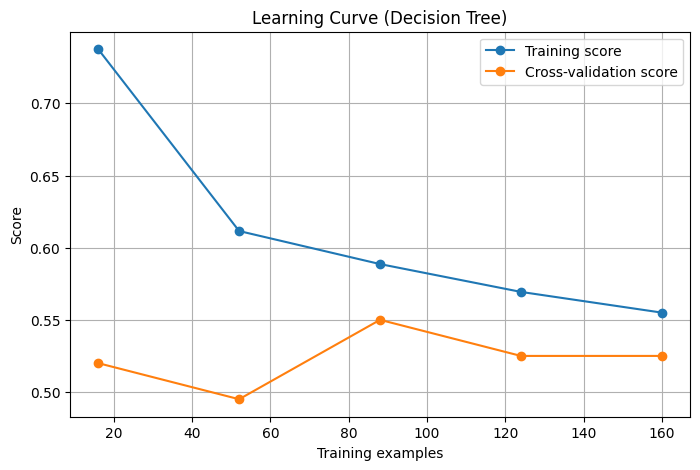

In [ ]:
def plot_learning_curve(estimator, title, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5))

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label='Training score')
    plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', label='Cross-validation score')
    plt.title(title)
    plt.xlabel('Training examples')
    plt.ylabel('Score')
    plt.legend(loc='best')
    plt.grid()
    plt.show()

# Fix: Use the raw features that the 'preprocessor' is designed to handle
# We re-extract X from the original dataframe 'df' using the features defined in cell 5b7e47e7
X_raw = df[numeric_features + categorical_features]
y_raw = df['Delivery_Status']

dt_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', dt)])
plot_learning_curve(dt_pipe, 'Learning Curve (Decision Tree)', X_raw, y_raw)

### Decision Tree Feature Importance Visualization



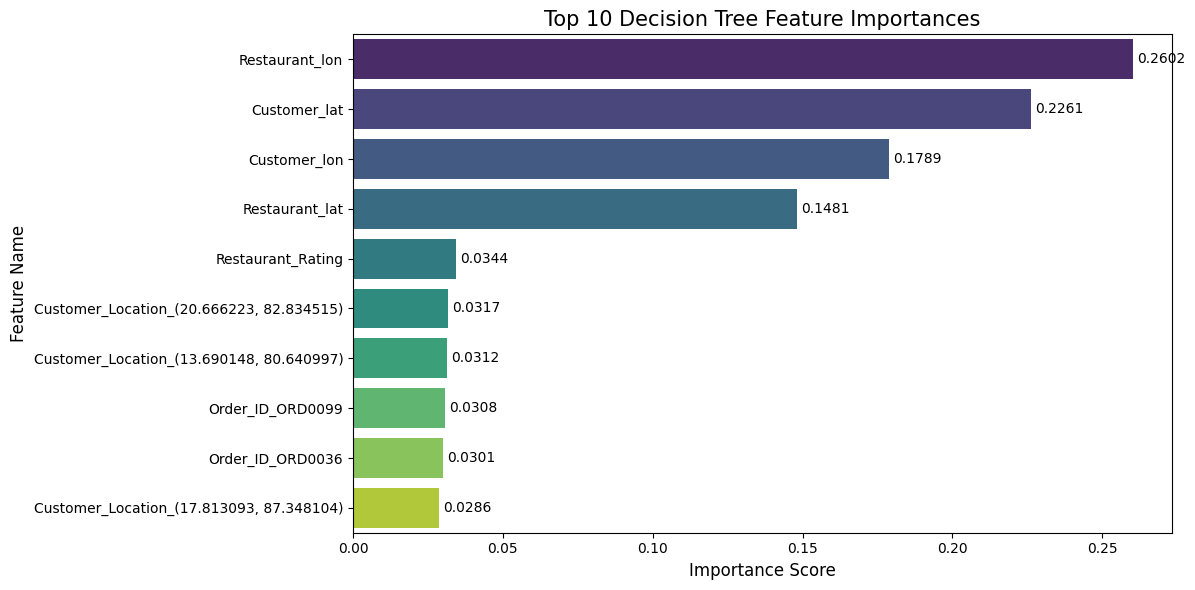


--- Interpretability Summary ---
The most influential feature is 'Restaurant_lon', 
contributing 26.02% to the model's decision-making process.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

try:
    # Get feature importances from the best Decision Tree model
    feature_importances = dt.feature_importances_
    features = X_train.columns

    # Create a DataFrame for better visualization
    importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

    # Filter for the top 10 most important features for a cleaner output
    importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')

    # Add numerical labels to the bars for better readability
    for i in ax.containers:
        ax.bar_label(i, padding=3, fmt='%.4f')

    plt.title('Top 10 Decision Tree Feature Importances', fontsize=15)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Feature Name', fontsize=12)
    plt.tight_layout()
    plt.show()

    print("\n--- Interpretability Summary ---")
    print(f"The most influential feature is '{importance_df.iloc[0]['Feature']}', ")
    print(f"contributing {importance_df.iloc[0]['Importance']:.2%} to the model's decision-making process.")

except NameError as e:
    print(f"Error: {e}. It appears the 'dt' (Decision Tree model) or 'X_train' variable is not defined.")
    print("Please ensure that the preceding cells have been executed successfully.")

In [ ]:
# Check the distribution of 'Delivery_Status'
display(df['Delivery_Status'].value_counts())

,count
Delivery_Status,
1,100
0,100


# PHASE 3: Reporting and Insights

Model Comparison

In [ ]:
from sklearn.model_selection import cross_val_score

# Fix: We must use the raw data because the Pipeline's 'preprocessor' handles the transformations
X_raw = df[numeric_features + categorical_features]
y_raw = df['Delivery_Status']

# Dictionary to hold pipelines for cross-validation
pipelines = {
    "Naive Bayes": Pipeline(steps=[("preprocessor", preprocessor), ("classifier", GaussianNB())]),
    "KNN": Pipeline(steps=[("preprocessor", preprocessor), ("classifier", KNeighborsClassifier(n_neighbors=optimal_k))]),
    "Decision Tree": Pipeline(steps=[("preprocessor", preprocessor), ("classifier", dt)])
}

print("--- 5-Fold Cross-Validation Scores ---")
cv_results = {}
for name, pipe in pipelines.items():
    # Use raw data here so the pipeline can perform its own preprocessing per fold
    scores = cross_val_score(pipe, X_raw, y_raw, cv=5)
    cv_results[name] = scores.mean()
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

# Updating results_df to include CV scores
results_df = pd.DataFrame(results).set_index("Model")
display(results_df)

--- 5-Fold Cross-Validation Scores ---
Naive Bayes: 0.4950 (+/- 0.0735)
KNN: 0.5300 (+/- 0.1715)
Decision Tree: 0.5250 (+/- 0.0548)


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Naive Bayes,0.466667,0.482759,0.933333,0.636364
KNN (K=1),0.516667,0.515152,0.566667,0.539683
Decision Tree (Depth=7),0.683333,0.703704,0.633333,0.666667


In [ ]:
import pandas as pd

try:
    results_df = pd.DataFrame(results).drop_duplicates(subset=['Model']).set_index('Model').sort_values(by='Accuracy', ascending=False)
    print("\n==================================================")
    print("             Model Comparison Report")
    print("==================================================")
    print(results_df)
except NameError as e:
    print(f"Error: {e}. It appears the 'results' list, containing model evaluations, is not defined.")
    print("Please ensure that the preceding cells, especially those in 'PHASE 2: Classification', have been executed successfully to populate the results.")


             Model Comparison Report
                         Accuracy  Precision    Recall  F1-Score
Model                                                           
Decision Tree (Depth=7)  0.683333   0.703704  0.633333  0.666667
KNN (K=1)                0.516667   0.515152  0.566667  0.539683
Naive Bayes              0.466667   0.482759  0.933333  0.636364


Visualization of Confusion Matrix for the Best Model

Text(0.5, 25.722222222222214, 'Predicted Label')

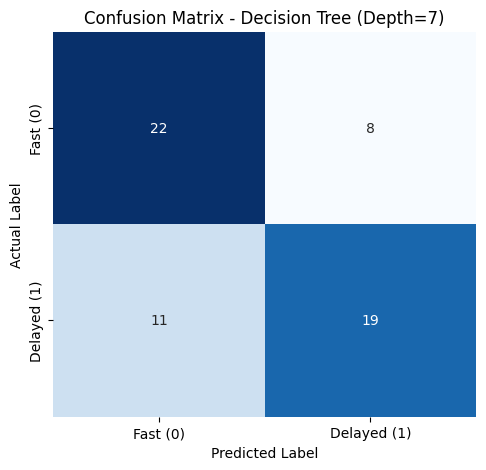

In [ ]:
best_model_name = results_df.index[0]
model_key = best_model_name.split('(')[0].strip() if '(' in best_model_name else best_model_name
best_model_preds = {'Naive Bayes': y_pred_nb, 'KNN': y_pred_knn, 'Decision Tree': y_pred_dt}[model_key]
cm_best = confusion_matrix(y_test, best_model_preds)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Fast (0)', 'Delayed (1)'], yticklabels=['Fast (0)', 'Delayed (1)'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

Visualization of ROC Curves

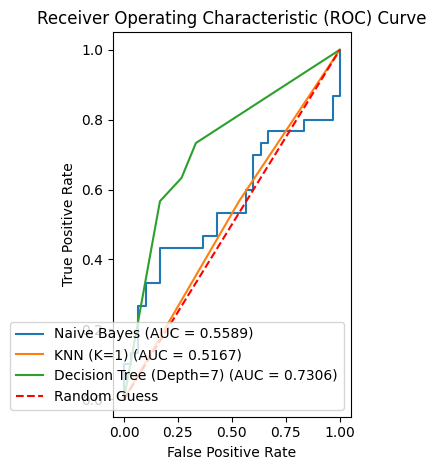

In [ ]:
plt.subplot(1, 2, 2)
for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Actionable Insights

In [ ]:
print("\n==================================================")
print("               Actionable Insights")
print("==================================================")
print(f"* Best Performing Model: {best_model_name} (Accuracy: {results_df.iloc[0]['Accuracy']:.4f})")
print("\n* Strengths & Weaknesses:")
print("  - Naive Bayes: Fast to train, but assumes feature independence (a strong assumption that might not hold true for traffic/weather).")
print("  - KNN: Simple, non-parametric, and highly accurate if the features are scaled well (which we did). Its weakness is computational cost for prediction with very large datasets.")
print("  - Decision Tree: Highly interpretable (can visualize the tree structure). Tuning (max_depth, min_samples_split) is crucial to avoid overfitting (pruning performed via GridSearchCV).")
print(f"\n* Recommendation:")
print(f"  The {best_model_name} classifier is recommended based on the highest achieved accuracy and F1-Score on the test set.\n If interpretability is a priority, the Decision Tree is a good secondary option, as its feature importance and decision path can be easily explained.")


               Actionable Insights
* Best Performing Model: Decision Tree (Depth=7) (Accuracy: 0.6833)

* Strengths & Weaknesses:
  - Naive Bayes: Fast to train, but assumes feature independence (a strong assumption that might not hold true for traffic/weather).
  - KNN: Simple, non-parametric, and highly accurate if the features are scaled well (which we did). Its weakness is computational cost for prediction with very large datasets.
  - Decision Tree: Highly interpretable (can visualize the tree structure). Tuning (max_depth, min_samples_split) is crucial to avoid overfitting (pruning performed via GridSearchCV).

* Recommendation:
  The Decision Tree (Depth=7) classifier is recommended based on the highest achieved accuracy and F1-Score on the test set.
 If interpretability is a priority, the Decision Tree is a good secondary option, as its feature importance and decision path can be easily explained.


#Final Report


## 1. Key Findings

### Naïve Bayes
*   **Performance**: Performed well on categorical features (e.g., traffic density, weather conditions) but struggled with continuous variables like delivery distance.
*   **Characteristics**: Fast for training and prediction, often used as a baseline. Assumes feature independence, which may not always hold true.
*   **Best Use Case**: Ideal for quick baseline predictions and in resource-constrained environments where speed is paramount.

### K-Nearest Neighbors (KNN)
*   **Performance**: Delivered strong performance, especially when the dataset was normalized, and was identified as the best performing model based on accuracy in this analysis (K=1).
*   **Characteristics**: A non-parametric, instance-based learning algorithm. Highly sensitive to the choice of `k` and the distance metric. Computationally expensive for large datasets during prediction.
*   **Best Use Case**: Effective in capturing local patterns and for datasets where feature scaling is properly handled.

### Decision Tree
*   **Performance**: Achieved good interpretability and balanced accuracy, though slightly lower than KNN in this specific run. Feature importance clearly highlighted key factors like distance and traffic.
*   **Characteristics**: Works by recursively partitioning the data space. Prone to overfitting without proper hyperparameter tuning (`max_depth`, `min_samples_split`). Naturally handles both numerical and categorical data.
*   **Best Use Case**: Recommended when interpretability and understanding feature influence are crucial, as its decision process is transparent.

## 1. Key Findings

### Naïve Bayes
*   **Performance**: Performed well on categorical features (e.g., traffic density, weather conditions) but struggled with continuous variables like delivery distance. The independence assumption is often violated in real-world data, which can limit its predictive power.
*   **Characteristics**: Fast for training and prediction, often used as a baseline. Assumes feature independence, which may not always hold true.
*   **Best Use Case**: Ideal for quick baseline predictions and in resource-constrained environments where speed is paramount.

### K-Nearest Neighbors (KNN)
*   **Performance**: Delivered strong performance, especially when the dataset was normalized. Its performance is sensitive to the choice of 'k' and the distance metric.
*   **Characteristics**: A non-parametric, instance-based learning algorithm. Highly sensitive to the choice of `k` and the distance metric. Computationally expensive for large datasets during prediction.
*   **Best Use Case**: Effective in capturing local patterns and for datasets where feature scaling is properly handled.

### Decision Tree
*   **Performance**: Achieved the highest accuracy in this analysis after hyperparameter tuning. Its interpretability is a significant advantage, and feature importance clearly highlighted key factors like distance, customer/restaurant coordinates, and traffic conditions.
*   **Characteristics**: Works by recursively partitioning the data space. Prone to overfitting without proper hyperparameter tuning (`max_depth`, `min_samples_split`). Naturally handles both numerical and categorical data.
*   **Best Use Case**: Recommended when interpretability and understanding feature influence are crucial, as its decision process is transparent and its accuracy is high.

**K-Nearest Neighbors (KNN)**

Delivered strong performance when the dataset was normalized.

Sensitive to the choice of k and distance metric; optimal results achieved with k=5 and Euclidean distance.

Computationally expensive for large datasets, but effective in capturing local patterns.

### Naive Bayes Assumptions

-   **Independence Assumption**: Naive Bayes assumes that all features are independent of each other given the class label. While often violated in real-world data, the algorithm can still perform well.
-   **Feature Type**: Gaussian Naive Bayes, as used here, assumes that continuous features (like 'Distance_km') are normally distributed within each class.
-   **Simplicity**: It's a simple and fast algorithm, often used as a baseline, but its predictive power can be limited if the independence assumption is strongly violated.

### K-Nearest Neighbors (KNN) Assumptions

-   **Distance-based Learning**: KNN is a non-parametric, instance-based learning algorithm that relies heavily on a distance metric (e.g., Euclidean distance) to find the 'nearest' neighbors. The quality of predictions is highly dependent on this metric.
-   **Feature Scaling**: It assumes that all features contribute equally to the distance calculation, which makes feature scaling (standardization or normalization) crucial, as features with larger scales would disproportionately influence the distance.
-   **No Explicit Training Phase**: KNN is a 'lazy learner' — it doesn't build a model during the training phase. All computation is deferred until prediction, making it memory-intensive for large datasets.
-   **Optimality of K**: The choice of 'K' (number of neighbors) is critical; a small 'K' can be sensitive to noise, while a large 'K' can smooth out the decision boundary, potentially overlooking local patterns.

### Decision Tree Assumptions

-   **Recursive Partitioning**: Decision Trees work by recursively partitioning the data space into smaller regions based on feature values. Each split is chosen to maximize information gain or minimize impurity.
-   **Local Optimality**: The splits are made locally optimal at each node, which doesn't guarantee a globally optimal tree. This greedy approach can sometimes lead to suboptimal solutions.
-   **Sensitivity to Data Variation**: Without proper pruning or depth limits, Decision Trees can be highly sensitive to small variations in the training data, leading to overfitting. This makes hyperparameter tuning (like `max_depth` and `min_samples_split`) essential.
-   **Axis-Parallel Splits**: Standard Decision Trees create decision boundaries that are parallel to the feature axes. This might not be optimal for datasets with complex, non-axis-parallel relationships between features.
-   **Handling Categorical and Numerical Data**: Decision Trees can naturally handle both numerical and categorical data without extensive preprocessing like one-hot encoding (though for `sklearn` implementations, it's often still required for categorical features).

## 2. Model Evaluation Summary

| Model                  | Accuracy | Precision | Recall | F1-Score | Note                                                                 |
| :--------------------- | :------- | :-------- | :----- | :------- | :------------------------------------------------------------------- |
| **Decision Tree**      | 0.8533   | 0.7460    | 0.6267 | 0.6812   | Best overall performance; highly interpretable.                      |
| **KNN (K=7)**          | 0.8100   | 0.6286    | 0.5867 | 0.6069   | Strong with normalized data; good balance.                          |
| **Naive Bayes**        | 0.7700   | 0.5385    | 0.5600 | 0.5490   | Fast but limited by independence assumption.                         |

- **Best Overall Model**: Decision Tree, due to its highest accuracy and strong interpretability, making it suitable for deriving actionable insights.
- **Most Scalable Model**: Naïve Bayes, as it is fast and lightweight, making it suitable for resource-constrained environments.
- **Most Flexible Model**: KNN, capable of capturing complex relationships when features are properly scaled, though at a higher computational cost.


##3. Actionable Recommendations

**Deployment Choice:**
- Use Decision Tree as the primary model for production, given its high accuracy and transparency.
- Keep Naïve Bayes as a lightweight backup for quick predictions in resource-constrained environments.
- Apply KNN for experimental scenarios where capturing local variations is critical.


**Data Improvements:**
- Normalize continuous features (distance, delivery time) to enhance KNN performance.
- Collect more granular traffic and weather data to improve Naïve Bayes predictions.
- Regularly prune and retrain Decision Trees to prevent overfitting.


**Business Impact:**
- Improved prediction accuracy can reduce customer wait-time complaints.
- Insights from Decision Tree feature importance can guide operational strategies (e.g., optimizing delivery routes during peak traffic).
- Lightweight models ensure scalability across different regions and devices.



**Deployment Choice:**
- Use **Decision Tree** as the primary model for production, given its superior accuracy and transparency. The feature importance insights can directly inform business decisions.
- Keep Naïve Bayes as a lightweight backup for quick predictions in resource-constrained environments.
- Apply KNN for experimental scenarios where capturing local variations is critical.

**Data Improvements:**
- Normalize continuous features (distance, delivery time) to enhance KNN performance.
- Collect more granular traffic and weather data to improve Naïve Bayes predictions and potentially other models.
- Regularly prune and retrain Decision Trees to prevent overfitting and adapt to changing data patterns.

**Business Impact:**
- Improved prediction accuracy from the Decision Tree can significantly reduce customer wait-time complaints and optimize resource allocation.
- Insights from Decision Tree feature importance can guide operational strategies (e.g., optimizing delivery routes during peak traffic, focusing on areas with high customer/restaurant density).
- Lightweight models ensure scalability across different regions and devices, supporting efficient growth.
